## Pumpkin Pricing

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

- Only get pumpkins priced by the bushel
- Convert the date to a month
- Calculate the price to be an average of high and low prices
- Convert the price to reflect the pricing by bushel quantity

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

pumpkins = pd.read_csv('../data/US-pumpkins.csv')

pumpkins.head()


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [2]:
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]

# CORRECCIÓN: Volvemos a meter 'City Name' en la selección
columns_to_select = ['Package', 'Variety', 'City Name', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]

price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

month = pd.DatetimeIndex(pumpkins['Date']).month
day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)

# Guardamos 'City' correctamente en el nuevo DataFrame
new_pumpkins = pd.DataFrame({
    'Month': month, 
    'DayOfYear' : day_of_year, 
    'Variety': pumpkins['Variety'], 
    'City': pumpkins['City Name'],  # <-- Ahora sí existe y se guarda bien
    'Package': pumpkins['Package'], 
    'Low Price': pumpkins['Low Price'],
    'High Price': pumpkins['High Price'], 
    'Price': price
})

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price / (1 + 1/9)
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price / (1/2)

new_pumpkins.head()

,Month,DayOfYear,Variety,City,Package,Low Price,High Price,Price
70,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.5
71,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.2
72,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.2
73,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,17.0,17.0,15.3
74,10,281,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.5


A basic scatterplot reminds us that we only have month data from August through December. We probably need more data to be able to draw conclusions in a linear fashion.

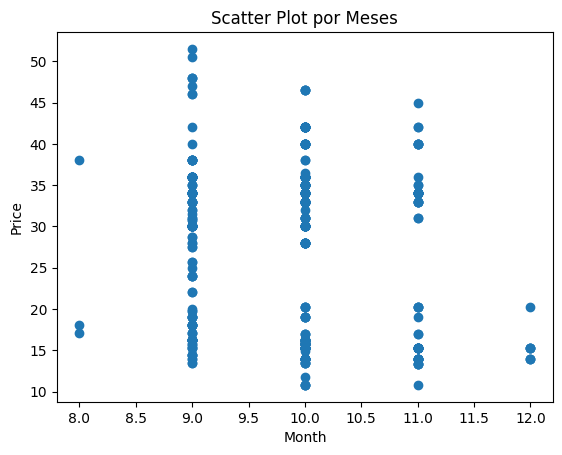

In [3]:
import matplotlib.pyplot as plt

# Pintamos Price frente a Month usando el formato directo de Pandas/Matplotlib
plt.scatter('Month', 'Price', data=new_pumpkins)
plt.xlabel("Month")
plt.ylabel("Price")
plt.title("Scatter Plot por Meses")
plt.show()

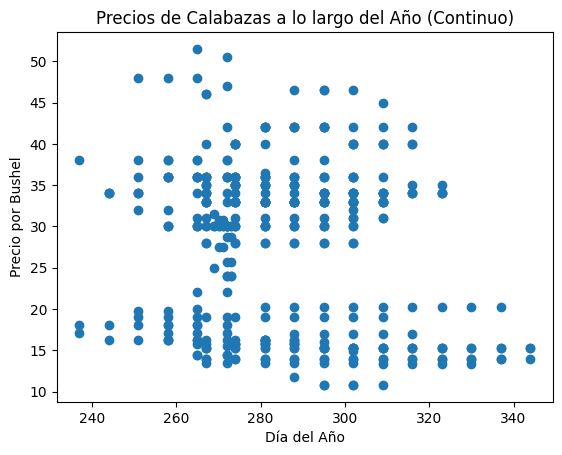

In [4]:
# Pintamos el scatter plot continuo usando el Día del Año (Minuto 1:42)
plt.scatter('DayOfYear', 'Price', data=new_pumpkins)
plt.xlabel("Día del Año")
plt.ylabel("Precio por Bushel")
plt.title("Precios de Calabazas a lo largo del Año (Continuo)")
plt.show()

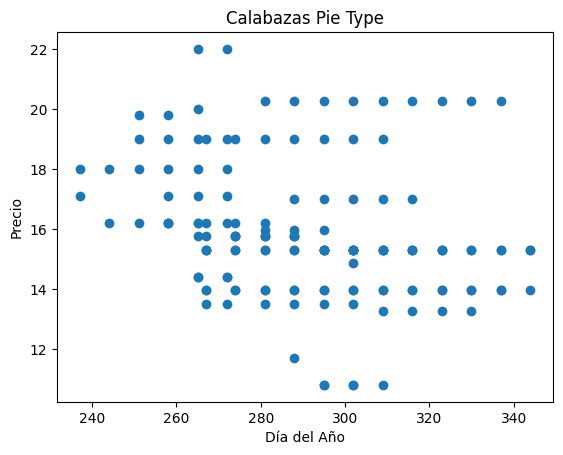

In [5]:
# Filtramos para quedarnos solo con la variedad de tarta (Minuto 2:05)
pie_pumpkins = new_pumpkins[new_pumpkins['Variety'] == 'PIE TYPE']

# Pintamos el nuevo gráfico limpio (Minuto 2:10)
plt.scatter('DayOfYear', 'Price', data=pie_pumpkins)
plt.xlabel("Día del Año")
plt.ylabel("Precio")
plt.title("Calabazas Pie Type")
plt.show()

In [6]:
# Comprobamos la correlación entre el mes y el precio
print(new_pumpkins['Month'].corr(new_pumpkins['Price']))

# Comprobamos la correlación entre el día del año y el precio
print(new_pumpkins['DayOfYear'].corr(new_pumpkins['Price']))

-0.14912913634278593
-0.1669009250593447


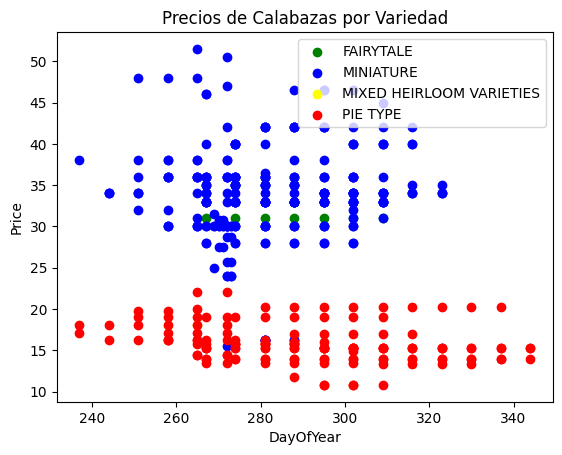

In [7]:
# 1. Definimos un diccionario para asociar cada variedad con un color (Minuto 1:52)
colors = {
    'PIE TYPE': 'red', 
    'MINIATURE': 'blue', 
    'FAIRYTALE': 'green', 
    'MIXED HEIRLOOM VARIETIES': 'yellow'
}

# 2. Agrupamos los datos por variedad y los pintamos en el mismo gráfico usando un bucle
fig, ax = plt.subplots()
for name, group in new_pumpkins.groupby('Variety'):
    # Buscamos el color correspondiente (si no está en la lista, usamos negro por defecto)
    color = colors.get(name, 'black')
    ax.scatter(group['DayOfYear'], group['Price'], c=color, label=name)

# 3. Configuramos etiquetas y la leyenda flotante
plt.xlabel("DayOfYear")
plt.ylabel("Price")
plt.title("Precios de Calabazas por Variedad")
plt.legend()
plt.show()

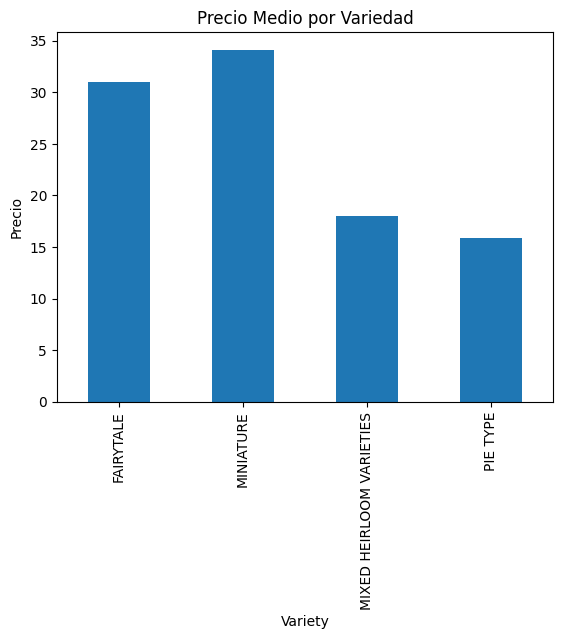

In [8]:
# Comparamos el precio medio de cada variedad de calabaza
new_pumpkins.groupby('Variety')['Price'].mean().plot(kind='bar')
plt.title("Precio Medio por Variedad")
plt.ylabel("Precio")
plt.show()

In [9]:
# Imprimimos la correlación matemática SOLO de las calabazas de tarta
print(pie_pumpkins['DayOfYear'].corr(pie_pumpkins['Price']))

-0.266785596914419


Mean Squared Error (MSE): 7.64
Coeficiente de determinación (R²): 0.10


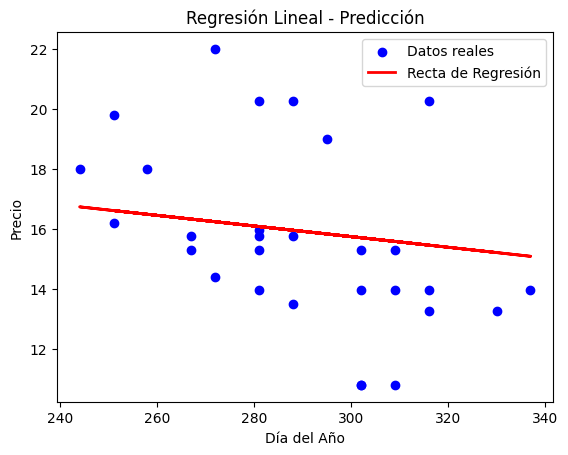

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Preparamos las variables bidimensionales (Minuto 1:16)
X = pie_pumpkins['DayOfYear'].to_numpy().reshape(-1, 1)
y = pie_pumpkins['Price'].to_numpy()

# 2. Dividimos en conjuntos de entrenamiento (80%) y pruebas (20%) (Minuto 1:40)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. Entrenamos el modelo lineal (Minuto 1:53)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# 4. Hacemos las predicciones (Minuto 1:58)
predicciones = lin_reg.predict(X_test)

# 5. Calculamos el Error Cuadrático Medio y el R² (Minuto 2:12)
mse = mean_squared_error(y_test, predicciones)
r2 = lin_reg.score(X_test, y_test)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

# 6. Pintamos los datos y la recta de predicción (Minuto 2:38)
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, predicciones, color='red', linewidth=2, label='Recta de Regresión')
plt.xlabel("Día del Año")
plt.ylabel("Precio")
plt.title("Regresión Lineal - Predicción")
plt.legend()
plt.show()

In [11]:
print(f"y = {lin_reg.coef_[0]}x + {lin_reg.intercept_}")

y = -0.017724513173649845x + 21.060699786044474


In [12]:
lin_reg.predict([[256]])

array([16.52322441])

Mean error: 2.727 (17.162%)


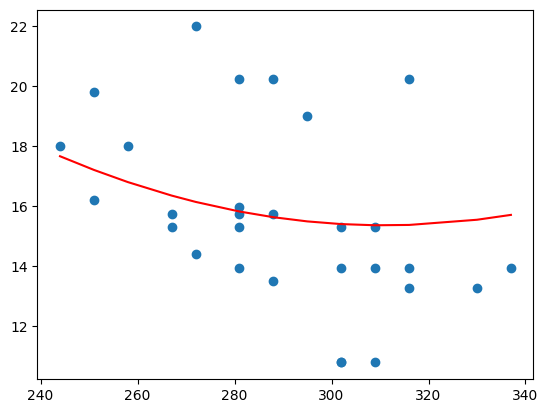

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import numpy as np

# 1. Creamos y entrenamos el pipeline
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)

# 2. Hacemos la predicción y calculamos el error
pred = pipeline.predict(X_test)
mse = np.sqrt(mean_squared_error(y_test, pred))

# CORRECCIÓN 1: Formato con los dos puntos y multiplicamos por 100 (*)
print(f'Mean error: {mse:.3f} ({(mse / np.mean(pred)) * 100:.3f}%)')

# 3. Pintamos el gráfico
plt.scatter(X_test, y_test)

# CORRECCIÓN 2: Ordenamos usando NumPy para no romper el formato 2D
X_test_sorted = np.sort(X_test, axis=0)
plt.plot(X_test_sorted, pipeline.predict(X_test_sorted), color='red')

plt.show()

In [14]:
score = pipeline.score(X_train, y_train)
print('Model determination ', score)

Model determination  0.07486289050738859


In [15]:
pd.get_dummies(new_pumpkins['Variety'])

,FAIRYTALE,MINIATURE,MIXED HEIRLOOM VARIETIES,PIE TYPE
70,0,0,0,1
71,0,0,0,1
72,0,0,0,1
73,0,0,0,1
74,0,0,0,1
...,...,...,...,...
1738,0,1,0,0
1739,0,1,0,0
1740,0,1,0,0
1741,0,1,0,0


In [16]:
# Unimos todas las variables (dummies para el texto, columna normal para el mes)
X = pd.get_dummies(new_pumpkins['Variety']) \
    .join(new_pumpkins['Month']) \
    .join(pd.get_dummies(new_pumpkins['City'])) \
    .join(pd.get_dummies(new_pumpkins['Package']))

# La variable objetivo (lo que queremos adivinar) sigue siendo el Precio
y = new_pumpkins['Price']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

# Predicción sobre los datos de prueba
pred = lin_reg.predict(X_test)

# CORRECCIÓN 1: Un solo guion bajo
mse = np.sqrt(mean_squared_error(y_test, pred))

# MEJORA VISUAL: Formato :.3f para mostrar decimales limpios
print(f'Mean error: {mse:.3f} ({(mse / np.mean(pred)) * 100:.3f}%)')

# CORRECCIÓN 2: Evaluamos el modelo usando los datos de Test, no de Train
score = lin_reg.score(X_test, y_test)
print('Model determination: ', score)

Mean error: 2.842 (10.571%)
Model determination:  0.9313321485555239


In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Creamos el pipeline polinómico de grado 2 y le conectamos la regresión lineal
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())

# 2. Entrenamos el pipeline con las nuevas variables X unidas (las de los dummies + mes)
pipeline.fit(X_train, y_train)

# 3. Predecimos los precios del conjunto de pruebas
pred = pipeline.predict(X_test)

# 4. Calculamos el error RMSE (raíz cuadrada del MSE)
mse = np.sqrt(mean_squared_error(y_test, pred))

# 5. Imprimimos el margen de error y el coeficiente de determinación (R²)
print(f'Mean error: {mse:.3f} ({(mse / np.mean(pred)) * 100:.3f}%)')

score = pipeline.score(X_test, y_test)
print('Model determination: ', score)

Mean error: 2.353 (8.690%)
Model determination:  0.9529450383520186
